From the `Bamboo_setup` directory, run the following command:
```bash
jupyter notebook --no-browser --port=8888
```
Copy the URL starting with `http://localhost:8888/`.
When picking the kernel for this notebook, click **Existing Jupyter Server** and paste the URL.
Name your server 'localhost'.
From localhost, select the 'Python 3' kernel.

In [1]:
import sys
from pathlib import Path
NOTEBOOKS = Path.cwd()                          # <-- Edit as needed
NN_POSTPROCESSING = NOTEBOOKS.parents[0]        # <-- Edit as needed
BAMBOO_SETUP = NOTEBOOKS.parents[3]             # <-- Edit as needed
Z_OUTPUT_eos = Path('/Users/antonett/Documents/HH Analysis/Z_OUTPUT_eos')   # <-- Edit as needed
sys.path.append(str((BAMBOO_SETUP/'src').resolve()))
import pandas as pd
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)  # Set a larger width to fit the editor window
# pd.set_option('display.max_colwidth', None)  # Allow columns to be fully displayed
%load_ext autoreload

### If any changes are made to the imported modules in this notebook, you must run this cell first to load the new changes (this will reload all modules)

In [8]:
%autoreload 2

# Set up a Data Handler (to load and preprocess all data)

In [19]:
from post_processing.NN.DataHandler import DataHandler
datahandler = DataHandler(
    workdir=Z_OUTPUT_eos/'2022_even_0815/Reco',
    tree_name='SL_res_2b_x'
    # total_inputs= NN_POSTPROCESSING / 'input/vars40.txt'
)
total_df = datahandler.load_data()
total_df = datahandler.fix_any_mismatch(total_df)
total_df = datahandler.preprocess_data(total_df)
# datahandler.data_quality_summary(total_df)

	Loading data...

Preprocessing data ...


# Set up your model config

In [3]:
from post_processing.NN.utils import ModelConfig
model_config = ModelConfig(
    name='multi_HH_ttbar_tW',
    type='multi',
    categorization={"HH": ["HH_bbWW"], "ttbar": ["ttbar"], "tW": ["tW"]},
    training_weight_sf={"HH_bbWW": 1.0, "ttbar": 8.0, "tW": 4.0},
    input_vars='All',
    architecture_in_yml=True,
    residual_network=False,
    hiddenlayers=[
        {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
        # {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4},
        # {"type": 'Dense', "units": 16, "activation": 'relu', "act_regularizer": {'l2': 1e-4}, "dropout_rate": 0.4}
    ],
    outputlayers=[
        {"type": 'Dense', "units": 3, "kernel_initializer": 'normal', "activation": 'softmax', "act_regularizer": {'l2': 1e-4}, "name": 'output'}
    ],
    compiler={"optimizer": 'adam', "lr": 0.001, "loss": 'categorical_crossentropy'},
    fit={"batch_size": 1024, "epochs": 2, "validation_split": 0.25}
)

# Run DNN

Initializing model: multi_HH_ttbar_tW
	Model dataframe:
            event   genWeight  nAK4  nAK4_btag  nAK8_btag     lep0_pt  lep0_eta  lep0_phi  ak4_jet0_pt  ak4_jet0_eta  ak4_jet0_phi  ak4_jet1_pt  ak4_jet1_eta  ak4_jet1_phi  ak4_jet2_pt  ak4_jet2_eta  ak4_jet2_phi  ak4_btag0_pt  ak4_btag0_eta  ak4_btag0_phi  ak4_btag1_pt  ak4_btag1_eta  ak4_btag1_phi      met_pt   met_phi   bjets_mbb  bjets_dPhi  bjets_dPhi_abs  bjets_dEta  bjets_dEta_abs  bjets_dR  bjets_pt_bb   bjet0_pt   bjet1_pt  bjets_mean_pt  trijet_mInv   trijet_pt  trijet_pt_rat     blnu_mT     blnu_pt  trijet_bijet_dR  trijet_bijet_dPhi  trijet_bijet_dEta  bjet_bijet_dR  bjet_bijet_dPhi  bjet_bijet_dEta      all_sT  all_sT_50_cut     all_mInv       all_mT  all_jets_HT      all_pt         mjj     WW_mInv  sample_weight  Class_HH  Class_ttbar  Class_tW
3233           50    0.033119     4          2          0   59.526562  0.090256 -0.759521     119.7500      0.111374     -1.221191     90.68750     -0.333191      1.946777    

Model: "multi_HH_ttbar_tW"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 52)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_3 (Masking) │ (None, 52)        │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 52)        │          0 │ masking_3[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_3         │ (None, 52)        │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_0 (Dense)     │ (None, 16)        │        848 │ normalization[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_3 (Any)         │ (None)            │          0 │ not_equal_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ layer_0[0][0],    │
│ (BatchNormalizatio… │                   │            │ any_3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │         51 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 963 (3.76 KB)

 Trainable params: 931 (3.64 KB)

 Non-trainable params: 32 (128.00 B)

	Training model ...
Epoch 1/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7227 - auc_pr: 0.7321 - auc_roc: 0.8359 - f1_score_macro: 0.3290 - f1_score_micro: 0.7227 - loss: 13.1347 - precision: 0.7829 - precision_HH: 0.0031 - precision_tW: 0.1900 - precision_ttbar: 0.9508 - recall: 0.2883 - recall_HH: 0.0129 - recall_tW: 0.0916 - recall_ttbar: 0.3005 - val_accuracy: 0.9112 - val_auc_pr: 0.9273 - val_auc_roc: 0.9695 - val_f1_score_macro: 0.3966 - val_f1_score_micro: 0.9112 - val_loss: 10.4184 - val_precision: 0.9301 - val_precision_HH: 0.0338 - val_precision_tW: 0.2753 - val_precision_ttbar: 0.9525 - val_recall: 0.8513 - val_recall_HH: 0.0838 - val_recall_tW: 0.1330 - val_recall_ttbar: 0.8957 - learning_rate: 0.0010
Epoch 2/2
704/704 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8948 - auc_pr: 0.9024 - auc_roc: 0.9597 - f1_score_macro: 0.3844 - f1_score_micro: 0.8948 - loss: 10.3786 - precision: 0.9132 - precision_HH: 0.0144 - precision_tW: 0.2094 - precision_ttbar: 0.9521 - 

({'accuracy': 0.9158249497413635,
  'auc_pr': 0.9258231520652771,
  'auc_roc': 0.9701528549194336,
  'f1_score_macro': 0.3997964859008789,
  'f1_score_micro': 0.9158248901367188,
  'loss': 0.49654415249824524,
  'precision': 0.9293392896652222,
  'precision_HH': 0.029036004096269608,
  'precision_tW': 0.29522964358329773,
  'precision_ttbar': 0.9524273872375488,
  'recall': 0.8793542385101318,
  'recall_HH': 0.14367815852165222,
  'recall_tW': 0.1455935835838318,
  'recall_ttbar': 0.9244624972343445},
 array([[0.25287356, 0.64942529, 0.09770115],
        [0.0096826 , 0.96137572, 0.02894168],
        [0.0208303 , 0.80531682, 0.17385288]]),
 array([[1.74603175e-02, 4.94285102e-04, 1.89944134e-03],
        [8.69047619e-01, 9.51140136e-01, 7.31396648e-01],
        [1.13492063e-01, 4.83655785e-02, 2.66703911e-01]]),
 ['HH', 'ttbar', 'tW'])

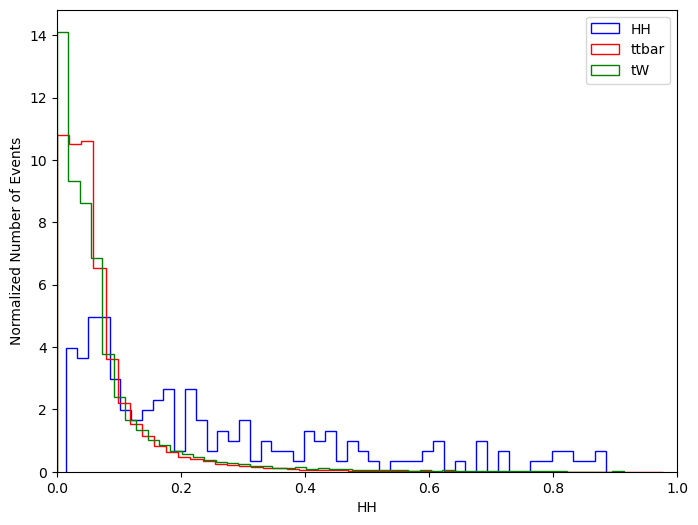

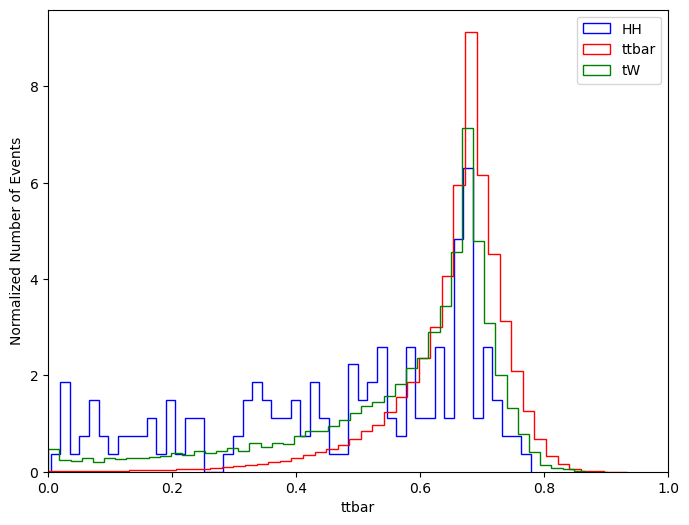

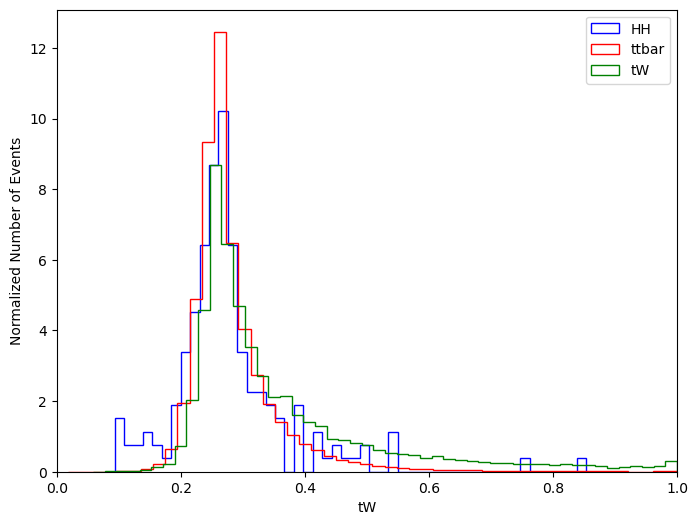

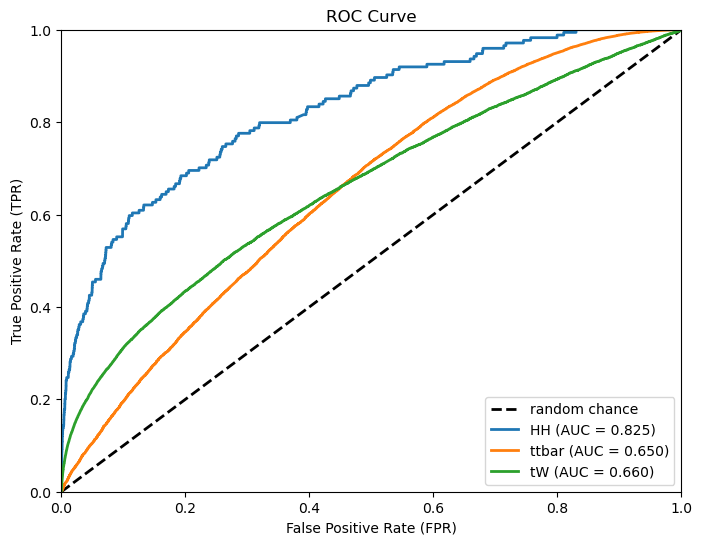

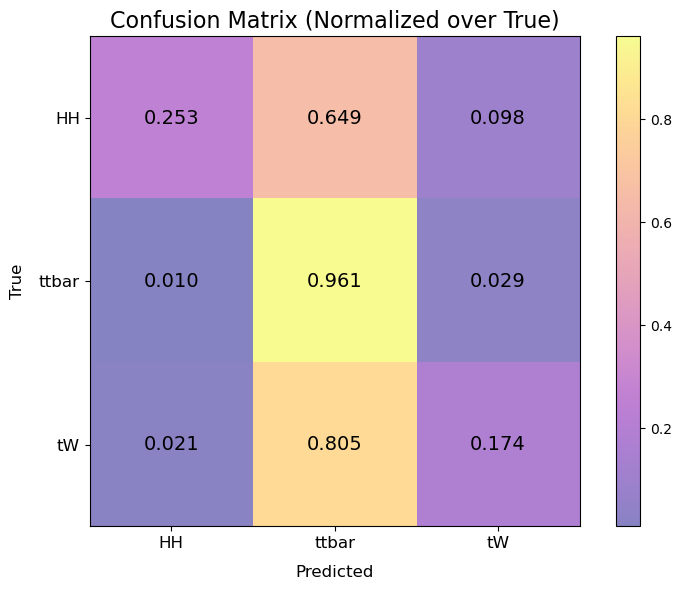

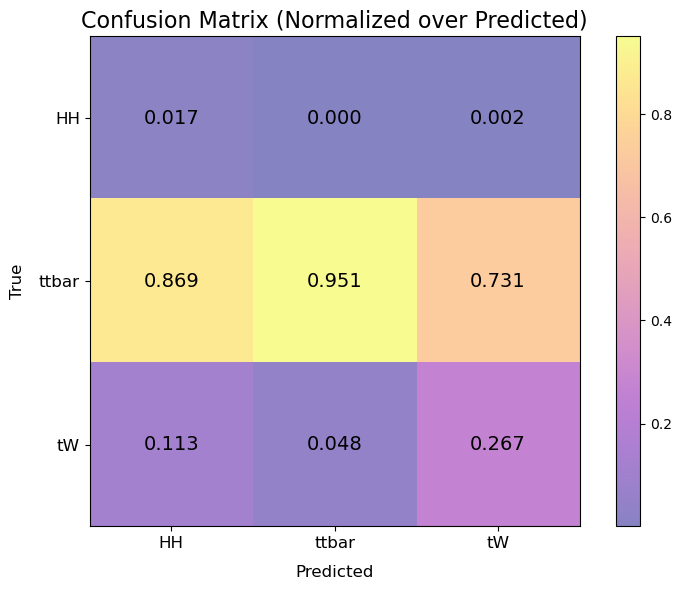

In [10]:
from post_processing.NN.DNNModel import DNNModel
DNN = DNNModel(model_config=model_config, modeldir= NOTEBOOKS/'model_custom_trial2')
DNN.Run(total_df, fixed_random_seed=True, save_model_info=False)